In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy import signal
from scipy.signal import wiener

from IPython.display import Audio, display
 

In [2]:
audio_path = "task5_1.wav"

fs, audio = wavfile.read(audio_path)

print("Sampling Rate:", fs, "Hz")
print("Number of Samples:", len(audio))
print("Duration:", len(audio) / fs, "seconds")
print("Data Type:", audio.dtype)

Sampling Rate: 48000 Hz
Number of Samples: 53625
Duration: 1.1171875 seconds
Data Type: int16


In [3]:
audio = audio.astype(np.float64)

# Normalize to range [-1, 1]
audio = audio / np.max(np.abs(audio))

print("Minimum:", audio.min())
print("Maximum:", audio.max())

Minimum: -1.0
Maximum: 1.0


In [4]:
display(Audio(audio, rate=fs))

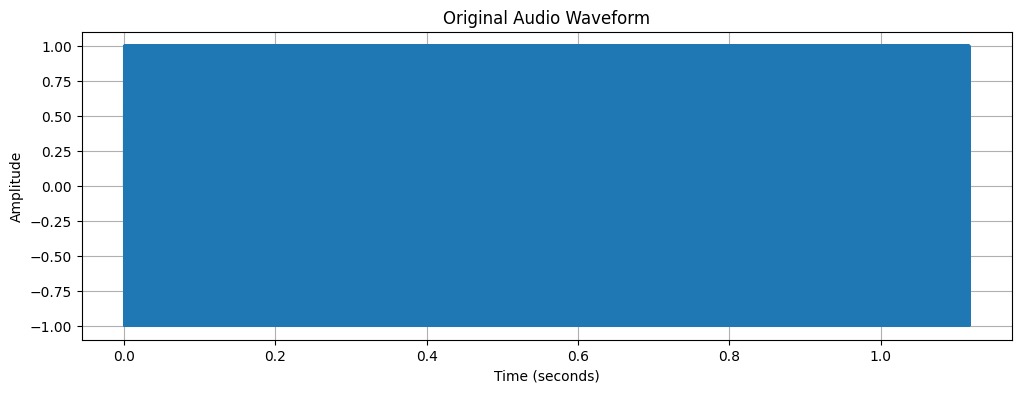

In [5]:
time = np.arange(len(audio)) / fs

plt.figure(figsize=(12, 4))

plt.plot(time, audio)

plt.title("Original Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

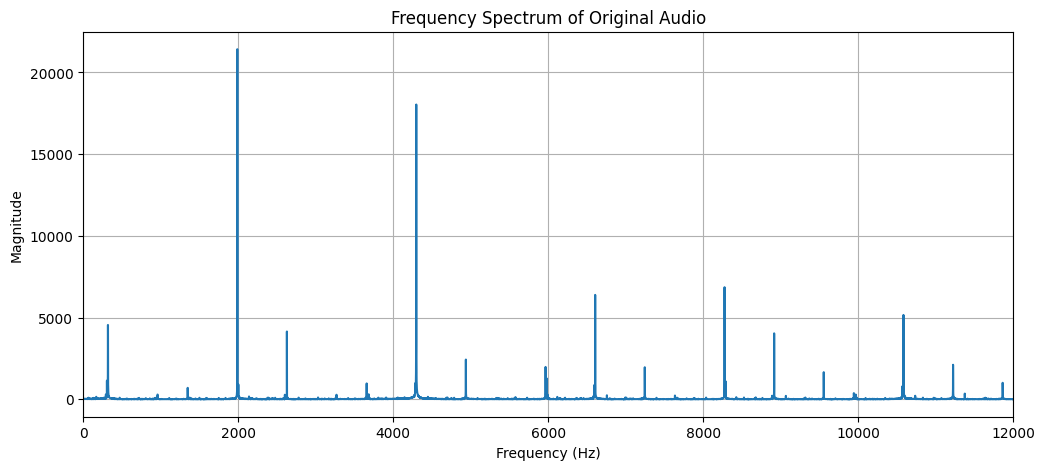

In [6]:
N = len(audio)

frequencies = np.fft.rfftfreq(N, d=1/fs)

fft_signal = np.fft.rfft(audio)
magnitude = np.abs(fft_signal)

plt.figure(figsize=(12, 5))

plt.plot(frequencies, magnitude)

plt.xlim(0, 12000)

plt.title("Frequency Spectrum of Original Audio")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.show()

In [7]:
# Buzz frequencies identified from the FFT
buzz_frequencies = [
    1989,
    4298,
    6607,
    8276
]

print("Buzz frequencies:")
for f in buzz_frequencies:
    print(f"{f} Hz")

Buzz frequencies:
1989 Hz
4298 Hz
6607 Hz
8276 Hz


In [8]:
notched_audio = audio.copy()

Q = 50

for f0 in buzz_frequencies:

    b, a = signal.iirnotch(
        w0=f0,
        Q=Q,
        fs=fs
    )

    notched_audio = signal.filtfilt(
        b,
        a,
        notched_audio
    )

print("Notch filtering completed.")

Notch filtering completed.


In [9]:
low_cutoff = 80
high_cutoff = 6000

sos = signal.butter(
    6,
    [low_cutoff, high_cutoff],
    btype="bandpass",
    fs=fs,
    output="sos"
)

bandpassed_audio = signal.sosfiltfilt(
    sos,
     notched_audio
)

print("Band-pass filtering completed.")

Band-pass filtering completed.


In [10]:
display(Audio(bandpassed_audio, rate=fs))

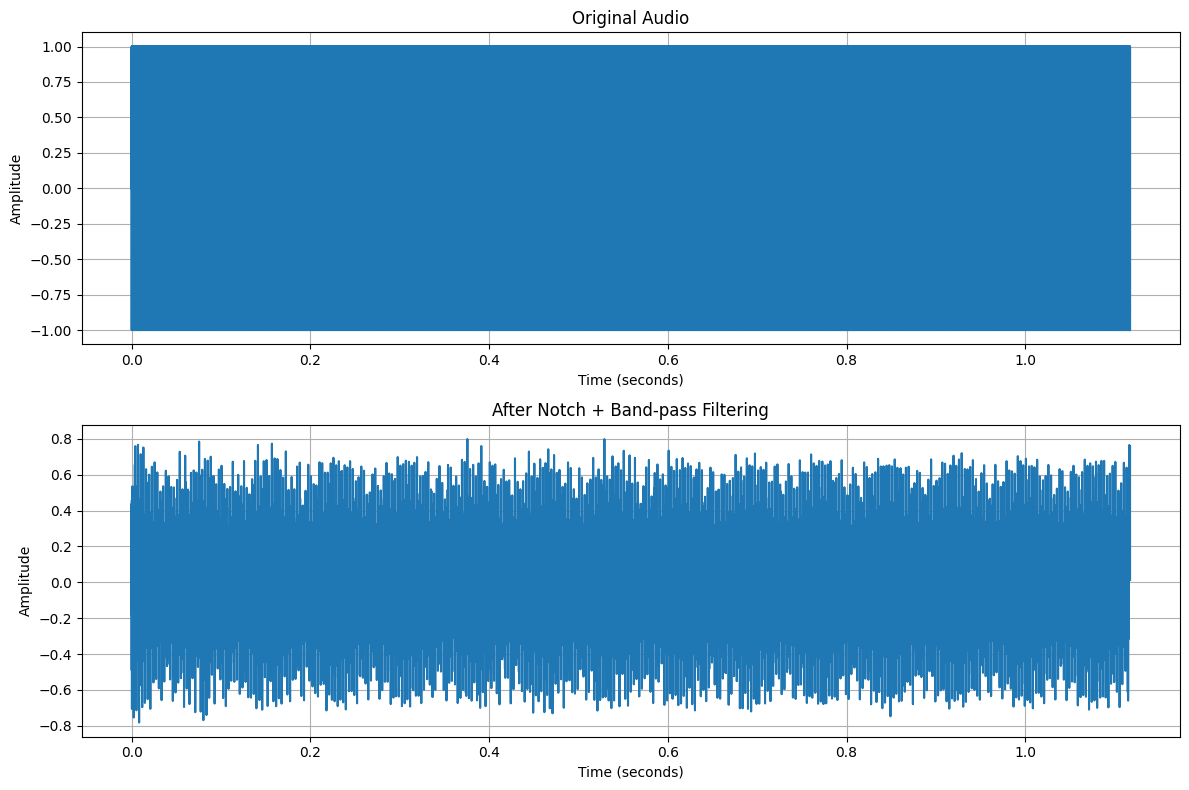

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)

plt.plot(time, audio)

plt.title("Original Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()


plt.subplot(2, 1, 2)

plt.plot(time, bandpassed_audio)

plt.title("After Notch + Band-pass Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()

plt.show()

In [12]:

# Apply Wiener filter
wiener_audio = wiener(bandpassed_audio)

# Convert to float32
wiener_audio = wiener_audio.astype(np.float32)

# Normalize to avoid clipping
wiener_audio = wiener_audio / (np.max(np.abs(wiener_audio)) + 1e-8)

 

print("Wiener filtered audio saved successfully!") 

Wiener filtered audio saved successfully!


In [13]:
nperseg = 1024
noverlap = 768

f, t, Zxx = signal.stft(
    wiener_audio ,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap
)

magnitude = np.abs(Zxx)
phase = np.angle(Zxx)

# Estimate stationary noise
# Median is useful because the buzz is present continuously
noise_estimate = np.median(
    magnitude,
    axis=1,
    keepdims=True
)

# Spectral subtraction
alpha = 1.5

clean_magnitude = magnitude - alpha * noise_estimate

# Prevent negative values
clean_magnitude = np.maximum(
    clean_magnitude,
    0
)

# Reconstruct complex STFT
clean_Zxx = (
    clean_magnitude *
    np.exp(1j * phase)
)

_, clean_audio = signal.istft(
    clean_Zxx,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap
)

# Make same length
clean_audio = clean_audio[:len(audio)]

print("Spectral subtraction completed.")

Spectral subtraction completed.


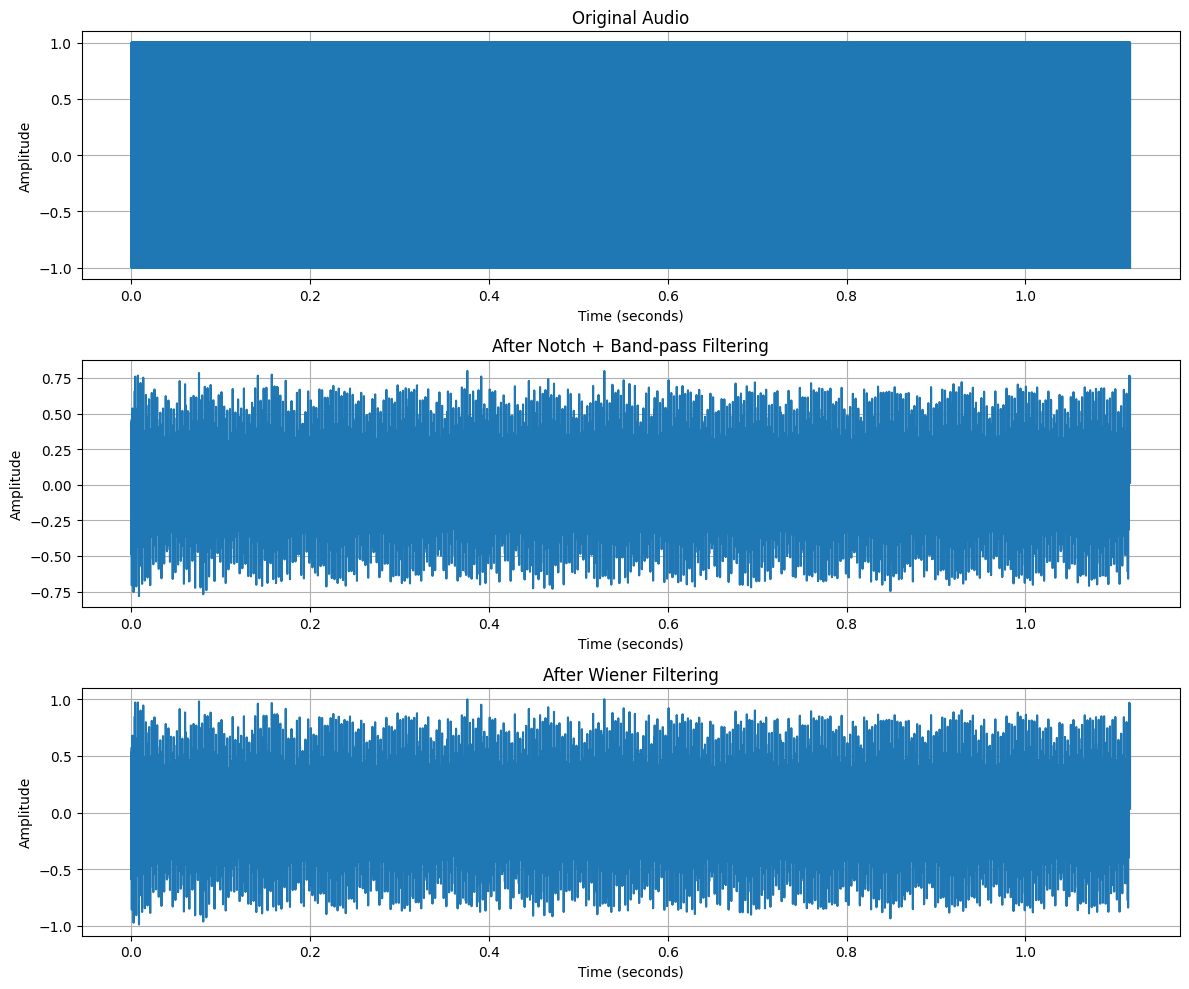

In [14]:
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(time, audio)
plt.title("Original Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, bandpassed_audio)
plt.title("After Notch + Band-pass Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time, wiener_audio)
plt.title("After Wiener Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
display(Audio(clean_audio, rate=fs))